# Условия ДЗ

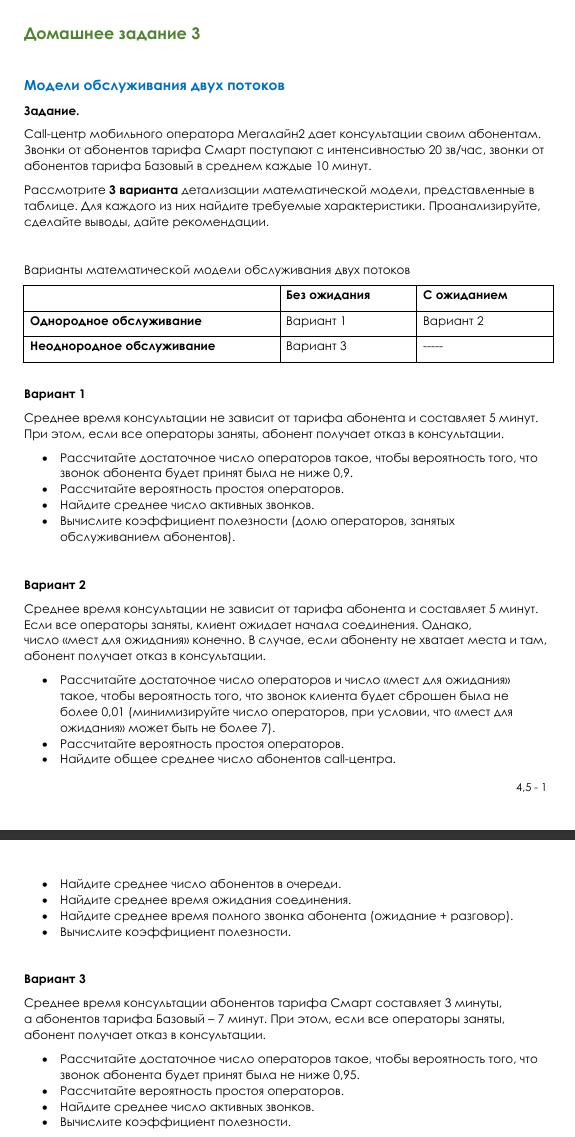

In [ ]:
import math, numpy as np
from scipy.special import factorial

#Вариант 1

In [ ]:
λ_smart,λ_basic  = 20,6
λ_total = λ_smart + λ_basic                                                      # общая интенсивность потока
μ_1 = 12
p_1 = λ_total / μ_1

                                                                                 # Создадим функцию для системы M|M|N|0

def mmn0(λ_val, μ_val, N):
    ρ = λ_val / μ_val
    pi_0 = 1.0 / sum([p_1**k / math.factorial(k) for k in range(N + 1)])
    pi_N = (p_1**N / math.factorial(N)) * pi_0
    P_reject = pi_N
    L_busy = p_1 * (1 - P_reject)                                                # Среднее число активных звонков
    P_idle = pi_0                                                                # Вероятность простоя операторов
    η = L_busy / N                                                               # Коэффициент полезности
    return P_reject, P_idle, L_busy, η, pi_0

N_1 = 1
while True:
    P_reject, P_idle, L_busy, η, pi_0 = mmn0(λ_total, μ_1, N_1)
    if P_reject <= 0.1:
        break
    N_1 += 1                                                                     # Достаточное число операторов

print('Ответ:')
print('Достаточное число операторов =', N_1)
print('Вероятность простоя операторов = ', round(P_idle,3))
print('Среднее число активных звонков =', round(L_busy,3))
print('Коэффициент полезности = ',round(η,3) )

Ответ:
Достаточное число операторов = 5
Вероятность простоя операторов =  0.117
Среднее число активных звонков = 2.066
Коэффициент полезности =  0.413


#Вариант 2

In [ ]:
                                                                                 # Создадим функцию для системы M|M|N|K

def mmnk(λ_val, μ_val, N, K):
    ρ = λ_val / μ_val
    sum1, sum2 = sum([ρ**k / math.factorial(k) for k in range(N + 1)]),sum([ρ**(N + m) / (math.factorial(N) * N**m) for m in range(1, K + 1)])
    pi_0 = 1.0 / (sum1 + sum2)

    pi = []
    for i in range(N + K + 1):
        if i <= N:
            pi_i = (ρ**i / math.factorial(i)) * pi_0
        else:
            pi_i = (ρ**i / (math.factorial(N) * N**(i - N))) * pi_0
        pi.append(pi_i)

    P_loss = pi[N + K]                                                           # Вероятность потери вызова
    P_wait = sum(pi[N:])
    L_queue = sum([(i - N) * pi[i] for i in range(N + 1, N + K + 1)])
    L_system = sum([i * pi[i] for i in range(1, N + K + 1)])                     # Среднее число абонентов в очереди
    L_busy = sum([min(i, N) * pi[i] for i in range(1, N + K + 1)])
    λ_served = λ_val * (1 - P_loss)
    W_queue = L_queue / λ_served                                                 # Среднее время ожидания
    W_system = L_system / λ_served                                               # Среднее время в системе
    η = L_busy / N                                                               # Коэффициент полезности
    P_idle = pi[0]

    return P_loss, P_idle, L_system, L_queue, W_queue, W_system, η

                                                                                 # Поиск оптимального N и K

best_N, best_K, min_operators = None, None, float('inf')

for K in range(1, 8):  # K от 1 до 7
    for N in range(1, 20):  # N от 1 до 20
        P_loss,_,_,_,_,_,_ = mmnk(λ_total, μ_1, N, K)
        if P_loss <= 0.01:
            if N < min_operators:
                min_operators = N
                best_N = N
                best_K = K
            break

P_loss, P_idle, L_system, L_queue, W_queue, W_system, η = mmnk(λ_total, μ_1, best_N, best_K)

print('Ответ:')
print('Оптимальное число операторов = ', (best_N))
print('Оптимальный размер очереди = ', (best_K))
#print('Вероятность потери вызова = ',round(P_loss,3))
print('Вероятность простоя операторов = ', round(P_idle,3))
print('Общее среднее число абонентов = ', round(L_system,3))
print('Среднее число абонентов в очереди = ', round(L_queue,3))
print('Среднее время ожидания соединения = ', round(W_queue,3), 'мин')
print('Среднее время полного звонка  = ',round(W_system,3),'мин')
print('Коэффициент полезности = ', round(η,3))

Ответ:
Оптимальное число операторов =  4
Оптимальный размер очереди =  4
Вероятность простоя операторов =  0.11
Общее среднее число абонентов =  2.344
Среднее число абонентов в очереди =  0.196
Среднее время ожидания соединения =  0.008 мин
Среднее время полного звонка  =  0.091 мин
Коэффициент полезности =  0.537


#Вариант 3

In [ ]:
                                                                                 # Функция для расчета характеристик СМО с двумя неоднородными потоками

μ_smart,μ_basic = 20,60/7

def heterogeneous(λ1, μ1, λ2, μ2, N):
    ρ1,ρ2 = λ1 / μ1 , λ2 / μ2
    G_sum = 0
    for k in range(N + 1):
        for h in range(N - k + 1):
            term = (ρ1**k / math.factorial(k)) * (ρ2**h / math.factorial(h))
            G_sum += term

    G = 1.0 / G_sum
    total_prob,L_busy,P_reject_total  = 0,0,0

    for k in range(N + 1):
        for h in range(N - k + 1):
            pi_kh = (ρ1**k / math.factorial(k)) * (ρ2**h / math.factorial(h)) * G
            total_prob += pi_kh
            busy_operators = k + h
            L_busy += busy_operators * pi_kh                                     # Среднее число активных звонков
            if busy_operators == N:
                P_reject_total += pi_kh                                          # Вероятность отказа

    P_idle = (ρ1**0 / math.factorial(0)) * (ρ2**0 / math.factorial(0)) * G       # Вероятность простоя операторов
    η = L_busy / N                                                               # Коэффициент полезности
    return P_reject_total, P_idle, L_busy, η

N_3 = 1                                                                          # Достаточное число операторов
while True:
    P_reject, P_idle, L_busy, η = heterogeneous(λ_smart, μ_smart, λ_basic, μ_basic, N_3)
    if P_reject <= 0.05:                                                         # Вероятность принятия ≥ 0.95
        break
    N_3 += 1

print('Ответ:')
print('Достаточное число операторов = ', round(N_3,3))
print('Вероятность простоя операторов = ',round(P_idle,3))
print('Среднее число активных звонков =', round(L_busy,3))
print('Коэффициент полезности = ', round(η,3))

Ответ:
Достаточное число операторов =  5
Вероятность простоя операторов =  0.184
Среднее число активных звонков = 1.663
Коэффициент полезности =  0.333


#Сравнительный анализ и выводы

In [ ]:
print('\nСРАВНЕНИЕ ВАРИАНТОВ:')

print('-' * 65)
print(f'{'Параметр':<25} {'Вариант 1':<12} {'Вариант 2':<12} {'Вариант 3':<12}')
print('-' * 65)
print(f'{'Число операторов':<25} {N_1:<12} {best_N:<12} {N_3:<12}')
print(f'{'Вероятность простоя':<25} {mmn0(λ_total, μ_1, N_1)[1]:.4f}       {mmnk(λ_total, μ_1, best_N, best_K)[1]:.4f}       {heterogeneous(λ_smart, μ_smart, λ_basic, μ_basic, N_3)[1]:.4f}')
print(f'{'Коэф. полезности':<25} {mmn0(λ_total, μ_1, N_1)[3]:.4f}       {mmnk(λ_total, μ_1, best_N, best_K)[6]:.4f}       {heterogeneous(λ_smart, μ_smart, λ_basic, μ_basic, N_3)[3]:.4f}')
print('-' * 65)

print('\nВЫВОДЫ:')
print('1. Вариант 1 (без ожидания):')
print('- Требует больше операторов для обеспечения качества обслуживания')
print('- Низкая утилизация операторов')
print('- Простая реализация, но высокие потери вызовов')

print('\n2. Вариант 2 (с ожиданием):')
print('- Наиболее эффективное использование операторов')
print('- Минимальные потери вызовов при оптимальном числе операторов')
print('- Требует организации системы ожидания')

print('\n3. Вариант 3 (неоднородное обслуживание):')
print('- Учитывает различия в времени обслуживания')
print('- Более точная модель реальной системы')
print('- Требует дифференцированного подхода к обслуживанию')

print('\nРЕКОМЕНДАЦИИ:')
print('Для call-центра рекомендуется Вариант 2 с очередью ожидания, \nтак как он обеспечивает наилучший баланс между качеством обслуживания, \nи эффективностью использования ресурсов операторов.')



СРАВНЕНИЕ ВАРИАНТОВ:
-----------------------------------------------------------------
Параметр                  Вариант 1    Вариант 2    Вариант 3   
-----------------------------------------------------------------
Число операторов          5            4            5           
Вероятность простоя       0.1173       0.1097       0.1842
Коэф. полезности          0.4131       0.5370       0.3326
-----------------------------------------------------------------

ВЫВОДЫ:
1. Вариант 1 (без ожидания):
- Требует больше операторов для обеспечения качества обслуживания
- Низкая утилизация операторов
- Простая реализация, но высокие потери вызовов

2. Вариант 2 (с ожиданием):
- Наиболее эффективное использование операторов
- Минимальные потери вызовов при оптимальном числе операторов
- Требует организации системы ожидания

3. Вариант 3 (неоднородное обслуживание):
- Учитывает различия в времени обслуживания
- Более точная модель реальной системы
- Требует дифференцированного подхода к обслу